## **Problem statement**
---


The real estate market generates a large volume of property listing data, but manually collecting and analyzing this information is time-consuming and inefficient. Home buyers, investors, and market analysts often need to compare property prices, locations, square footage, and other features to identify market trends and make informed decisions. However, this data is typically scattered across multiple listing pages, making comprehensive analysis difficult.

This project aims to automate the collection of publicly available property listing data from Redfin using Python and BeautifulSoup. The scraped data will be cleaned, transformed, and analyzed using Pandas to ensure accuracy and consistency. Exploratory Data Analysis (EDA) and data visualization techniques will then be applied to uncover pricing trends, relationships between property features, and market insights. The final outcome is a structured dataset and an analytical report that demonstrates how web scraping and data analytics can support data-driven decision-making in the real estate domain.

In [1]:
pip install beautifulsoup4

In [2]:
pip install curl_cffi beautifulsoup4

In [3]:
import random
import time
from bs4 import BeautifulSoup
from curl_cffi import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [4]:
# Base URL for Tampa, FL
base_url = "https://www.redfin.com/city/18142/FL/Tampa"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8",
    "Accept-Language": "en-US,en;q=0.9",
    "Accept-Encoding": "gzip, deflate, br",
    "Referer": "https://www.google.com/",
    "Connection": "keep-alive",
}

# Define how many pages you want to collect
total_pages = 10
all_properties = []

for page_num in range(1, total_pages + 1):
    # Handle pagination naming logic
    if page_num == 1:
        target_url = base_url
    else:
        target_url = f"{base_url}/page-{page_num}"

    print(f"Scraping {target_url}...")

    try:
        response = requests.get(target_url, headers=headers, impersonate="chrome")
    except Exception as e:
        print(f"Request failed on Page {page_num}: {e}")
        break

    if response.status_code != 200:
        print(f"Stopped at Page {page_num}. Status Code: {response.status_code}")
        break

    soup = BeautifulSoup(response.content, "html.parser")
    listings = soup.find_all("div", class_="HomeCardContainer")

    print(f"Found {len(listings)} home cards on Page {page_num}.")

    for card in listings:
        # 1. Price
        price_element = card.find("span", class_="bp-Homecard__Price--value")
        price = (
            price_element.get_text(strip=True) if price_element else "N/A"
        )

        # 2. Address (Flexible fallback logic built in)
        address_element = card.find("a", class_="bp-Homecard__Address")
        if not address_element:
            address_element = card.find("div", class_=lambda x: x and "Address" in x)

        address = (
            address_element.get_text(strip=True)
            if address_element
            else "N/A"
        )

        # 3. Stats (Beds, Baths, Sqft)
        beds_element = card.find("span", class_="bp-Homecard__Stats--beds")
        baths_element = card.find("span", class_="bp-Homecard__Stats--baths")
        sqft_element = card.find("span", class_="bp-Homecard__Stats--sqft")

        beds = beds_element.get_text(strip=True) if beds_element else "N/A"
        baths = baths_element.get_text(strip=True) if baths_element else "N/A"
        area = sqft_element.get_text(strip=True) if sqft_element else "N/A"


        # Append dictionary object to our list
        all_properties.append({
            "Price": price,
            "Address": address,
            "Beds": beds,
            "Baths": baths,
            "Area": area,
        })

    # Variable delay to play nice with their servers
    sleep_time = random.uniform(3, 6)
    print(f"Waiting {sleep_time:.2f} seconds...\n")
    time.sleep(sleep_time)

raw_df = pd.DataFrame(all_properties)

print(f"\nFinal Data Frame Created! Total Rows: {len(raw_df)}")

Scraping https://www.redfin.com/city/18142/FL/Tampa...
Found 43 home cards on Page 1.
Waiting 4.38 seconds...

Scraping https://www.redfin.com/city/18142/FL/Tampa/page-2...
Found 43 home cards on Page 2.
Waiting 3.24 seconds...

Scraping https://www.redfin.com/city/18142/FL/Tampa/page-3...
Found 43 home cards on Page 3.
Waiting 5.31 seconds...

Scraping https://www.redfin.com/city/18142/FL/Tampa/page-4...
Found 43 home cards on Page 4.
Waiting 3.01 seconds...

Scraping https://www.redfin.com/city/18142/FL/Tampa/page-5...
Found 43 home cards on Page 5.
Waiting 5.23 seconds...

Scraping https://www.redfin.com/city/18142/FL/Tampa/page-6...
Found 43 home cards on Page 6.
Waiting 5.38 seconds...

Scraping https://www.redfin.com/city/18142/FL/Tampa/page-7...
Stopped at Page 7. Status Code: 202

Final Data Frame Created! Total Rows: 258


As we can see that Status Code 202 which means redfin blocks the pagination from 7 so its give the data from page 1-6

In [5]:
raw_df

,Price,Address,Beds,Baths,Area
0,"$735,000","20302 Chestnut Grove Dr, Tampa, FL 33647",4 beds,2.5 baths,"3,002sq ft"
1,"$724,900","16909 Rolling Rock Dr, Tampa, FL 33618",4 beds,2.5 baths,"2,454sq ft"
2,N/A,N/A,N/A,N/A,N/A
3,"$1,350,000","Undisclosed address, Tampa, FL 33611",5 beds,3.5 baths,"3,035sq ft"
4,"$360,000","8709 Busch Oaks St, Tampa, FL 33617",3 beds,2 baths,"1,260sq ft"
...,...,...,...,...,...
253,"$100,000","8414 Lucuya Way #201, Temple Terrace, FL 33637",1 bed,1 bath,702sq ft
254,"$350,000","1109 E New Orleans Ave, Tampa, FL 33603",3 beds,2 baths,988sq ft
255,"$410,000","3716 Cat Mint St, Tampa, FL 33619",4 beds,2 baths,"1,935sq ft"
256,"$630,000","17823 Arbor Creek Dr, Tampa, FL 33647",5 beds,3 baths,"3,221sq ft"


In [6]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 258 entries, 0 to 257
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Price    258 non-null    object
 1   Address  258 non-null    object
 2   Beds     258 non-null    object
 3   Baths    258 non-null    object
 4   Area     258 non-null    object
dtypes: object(5)
memory usage: 10.2+ KB


In [7]:
raw_df.isnull().sum()

,0
Price,0
Address,0
Beds,0
Baths,0
Area,0


Because every entity is in object format it shows no null value

Let begin with cleaning

In [8]:
df=raw_df.copy()

Remove the dollar symbol and comas from the string and make it into float for the price.

In [9]:
df['Price'] = df['Price'].str.replace('$', '').str.replace(',', '')
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

Now for the beds bath and area get only digits and format should be float.

In [10]:
df['Beds'] = df['Beds'].str.extract(r'(\d+)').astype(float)
df['Baths'] = df['Baths'].str.extract(r'(\d+)').astype(float)

df['Area'] = df['Area'].str.replace('sq ft', '').str.replace(',', '')
df['Area'] = pd.to_numeric(df['Area'], errors='coerce')

As we can see Address column is full address, let break it down into meaningful columns with street, city, state and zip code.


To Break it down we just seprate address from ',' and put in different columns like street,city,state and zipcode

In [11]:
regex_pattern = r"^(?P<Street>.*),\s*(?P<City>[^,]+),\s*(?P<State>[A-Z]{2})\s*(?P<ZipCode>\d{5})"
extracted_address = df["Address"].str.extract(regex_pattern)

df = pd.concat([df, extracted_address], axis=1)

In [12]:
for index, row in df[df["ZipCode"].isna()].iterrows():
    parts = [p.strip() for p in row["Address"].split(",")]
    if len(parts) >= 3:
        df.at[index, "Street"] = parts[0]
        df.at[index, "City"] = parts[1]
        # Handles separating "FL 33602" by space
        state_zip = parts[2].split()
        if len(state_zip) == 2:
            df.at[index, "State"] = state_zip[0]
            df.at[index, "ZipCode"] = state_zip[1]

In [13]:
df=df.drop(columns=["Address"])

In [14]:
df.isnull().sum()

,0
Price,12
Beds,12
Baths,12
Area,12
Street,12
City,12
State,12
ZipCode,12


In [15]:
df=df.dropna()

In [16]:
df.head()

,Price,Beds,Baths,Area,Street,City,State,ZipCode
0,735000.0,4.0,2.0,3002.0,20302 Chestnut Grove Dr,Tampa,FL,33647
1,724900.0,4.0,2.0,2454.0,16909 Rolling Rock Dr,Tampa,FL,33618
3,1350000.0,5.0,3.0,3035.0,Undisclosed address,Tampa,FL,33611
4,360000.0,3.0,2.0,1260.0,8709 Busch Oaks St,Tampa,FL,33617
5,360000.0,3.0,2.0,1296.0,8420 N River Dune St,Tampa,FL,33617


In [17]:
df['Price_Per_SqFt'] = (df['Price'] / df['Area']).round(2)

In [18]:
df.tail()

,Price,Beds,Baths,Area,Street,City,State,ZipCode,Price_Per_SqFt
253,100000.0,1.0,1.0,702.0,8414 Lucuya Way #201,Temple Terrace,FL,33637,142.45
254,350000.0,3.0,2.0,988.0,1109 E New Orleans Ave,Tampa,FL,33603,354.25
255,410000.0,4.0,2.0,1935.0,3716 Cat Mint St,Tampa,FL,33619,211.89
256,630000.0,5.0,3.0,3221.0,17823 Arbor Creek Dr,Tampa,FL,33647,195.59
257,620000.0,4.0,2.0,1731.0,12321 Glenfield Ave,Tampa,FL,33626,358.17


Now our data is well cleaned and understandable.

In [19]:
df.describe()

,Price,Beds,Baths,Area,Price_Per_SqFt
count,2.460000e+02,246.000000,246.000000,246.000000,246.000000
mean,6.597243e+05,3.341463,2.313008,1914.044715,322.905285
std,5.661094e+05,1.472631,0.987469,934.021484,155.944223
min,7.900000e+04,1.000000,1.000000,550.000000,98.680000
25%,3.492250e+05,3.000000,2.000000,1297.500000,228.572500
50%,4.774500e+05,3.000000,2.000000,1677.000000,293.515000
75%,6.996000e+05,4.000000,3.000000,2175.750000,355.320000
max,3.000000e+06,18.000000,8.000000,5930.000000,1391.150000


In [20]:
# Number of houses group by zipcode
house_counts = df['ZipCode'].value_counts().reset_index()
house_counts.columns = ['ZipCode', 'House_Count']

# calculate the market share by zipcode
total_houses = len(df)
house_counts['Market_Share_%'] = (house_counts['House_Count'] / total_houses) * 100

print("--- Top Areas with the Most Houses for Sale ---")
print(house_counts.to_string(index=False))

--- Top Areas with the Most Houses for Sale ---
ZipCode  House_Count  Market_Share_%
  33647           21        8.536585
  33626           16        6.504065
  33615           15        6.097561
  33605           15        6.097561
  33602           15        6.097561
  33611           14        5.691057
  33617           13        5.284553
  33618           13        5.284553
  33629           13        5.284553
  33609           10        4.065041
  33624           10        4.065041
  33625           10        4.065041
  33614            8        3.252033
  33604            8        3.252033
  33603            8        3.252033
  33616            7        2.845528
  33619            7        2.845528
  33612            7        2.845528
  33610            6        2.439024
  33607            6        2.439024
  33634            6        2.439024
  33613            6        2.439024
  33635            5        2.032520
  33606            3        1.219512
  33637            3       

# **Visualization**

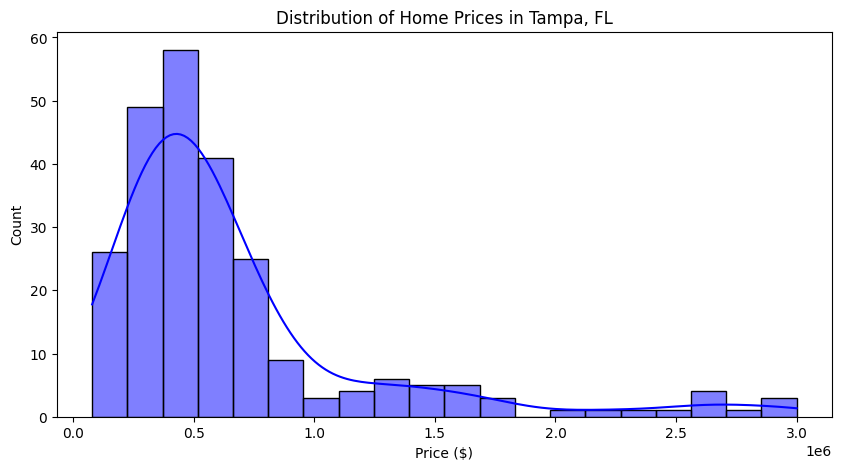

In [21]:
plt.figure(figsize=(10, 5))
sns.despine()
# Plot 1: Distribution of housing prices
sns.histplot(df['Price'], bins=20, kde=True, color='blue')
plt.title('Distribution of Home Prices in Tampa, FL')
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.show()

I plotted a Histogram with a Kernel Density Estimate (KDE) to understand the overall shape and spread of property prices in Tampa. It shows a right-skewed distribution, meaning most properties are clustered in a predictable baseline market tier, while a few luxury properties stretch the curve out to the right. This tells us that standard averages will be skewed upward, so the median price is a better measure of central tendency for this market.

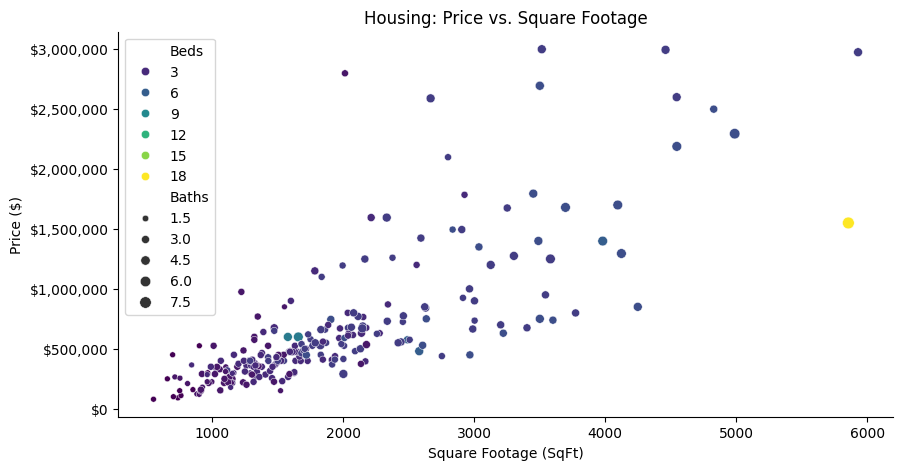

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.scatterplot(data=df, x='Area', y='Price', hue='Beds', palette='viridis', size='Baths')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"${int(x):,}"))
plt.title('Housing: Price vs. Square Footage')
plt.xlabel('Square Footage (SqFt)')
plt.ylabel('Price ($)')
sns.despine()
plt.show()

I used a Scatter Plot to map Price against Square Footage to visualize their direct relationship. It clearly demonstrates a strong, positive linear trend: as square footage goes up, price scales up predictably. The tightness of the data points along that upward trajectory shows that square footage is an excellent, highly dependable feature for predicting a home's base value.

As here we can see at a price of 14 Million price is seems to be outlier for this. Let we check removing of outlier is effecting our statistical comparison.

In [23]:
#To handle outlier I created df without outlier and df to check whether it effect statical analysis
df_without_outlier = df[df['Price'] < 10000000]

rate_with_outlier = (df['Price'] / df['Area']).median()
rate_without_outlier = (df_without_outlier['Price'] / df_without_outlier['Area']).median()

print("----Statistical Comparison----")
print(f"Median Price/SqFt (With Outlier):    ${rate_with_outlier:.2f}")
print(f"Median Price/SqFt (Without Outlier): ${rate_without_outlier:.2f}")

----Statistical Comparison----
Median Price/SqFt (With Outlier):    $293.52
Median Price/SqFt (Without Outlier): $293.52


As here we can see that median of outlier and non outlier is nearly same. so droping this will not harm any statistical comparison further.

Note: Because the data is changing regularly it may seem some changes as per the Redfin Website. Mostly the prices are matching with sqft.

In [24]:
df=df[df['Price'] <= 10000000]

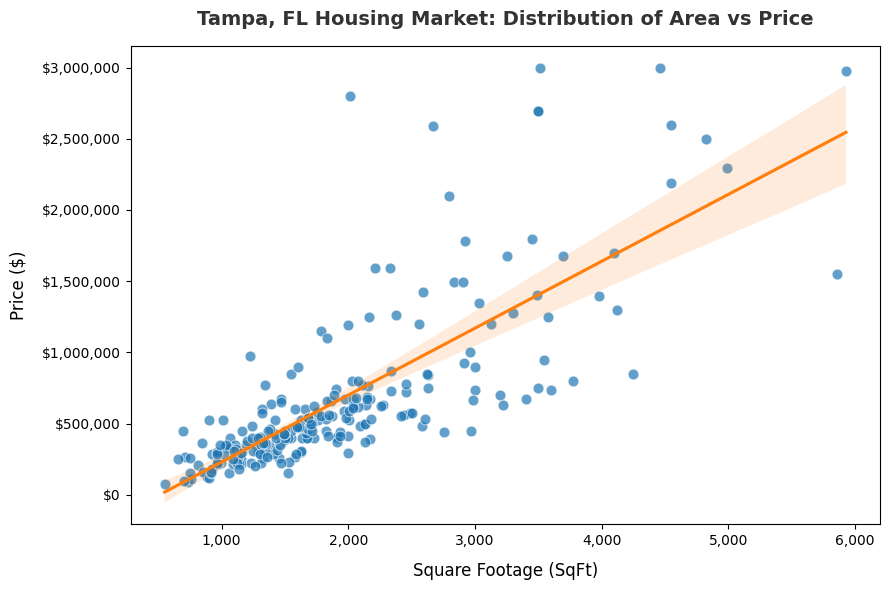

In [25]:
fig, ax = plt.subplots(figsize=(9, 6))

# Created a scatter plot
sns.scatterplot(
    data=df,
    x="Area",
    y="Price",
    alpha=0.7,
    color="#1f77b4",
    edgecolor="w",
    s=60,
    ax=ax,
)
sns.regplot(data=df, x="Area", y="Price", scatter=False, color="#ff7f0e", ax=ax)

# For Styling
ax.set_title(
    "Tampa, FL Housing Market: Distribution of Area vs Price",
    fontsize=14,
    pad=15,
    fontweight="bold",
    color="#333333",
)
ax.set_xlabel("Square Footage (SqFt)", fontsize=12, labelpad=10)
ax.set_ylabel("Price ($)", fontsize=12, labelpad=10)

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"${int(x):,}"))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{int(x):,}"))

plt.tight_layout()
plt.savefig("area_vs_price_distribution.png", dpi=300)

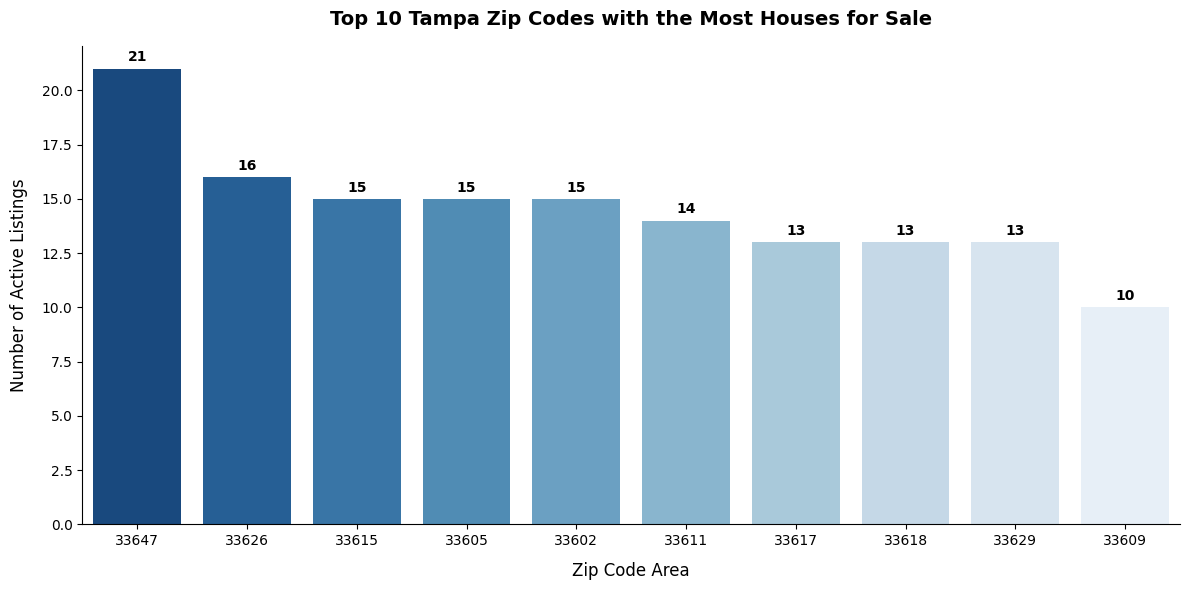

In [26]:
fig, ax = plt.subplots(figsize=(12, 6))

top_10_areas = house_counts.head(10)
sns.barplot(
    data=top_10_areas,
    x='ZipCode',
    y='House_Count',
    palette='Blues_r',
    hue='ZipCode',
    legend=False,
    ax=ax
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=10, fontweight='bold')

ax.set_title('Top 10 Tampa Zip Codes with the Most Houses for Sale', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('Zip Code Area', fontsize=12, labelpad=10)
ax.set_ylabel('Number of Active Listings', fontsize=12, labelpad=10)

plt.tight_layout()
sns.despine()
plt.show()

In [27]:
zip_median=df.groupby('ZipCode')['Price'].median().reset_index()
zip_median=zip_median.sort_values(by='Price',ascending=False)

top_5_expensive=zip_median.head().copy()
top_5_least=zip_median.tail().copy()

top_5_expensive['Category'] = 'Most Expensive'
top_5_least['Category'] = 'Least Expensive'

for_plot = pd.concat([top_5_expensive, top_5_least]).reset_index(drop=True)

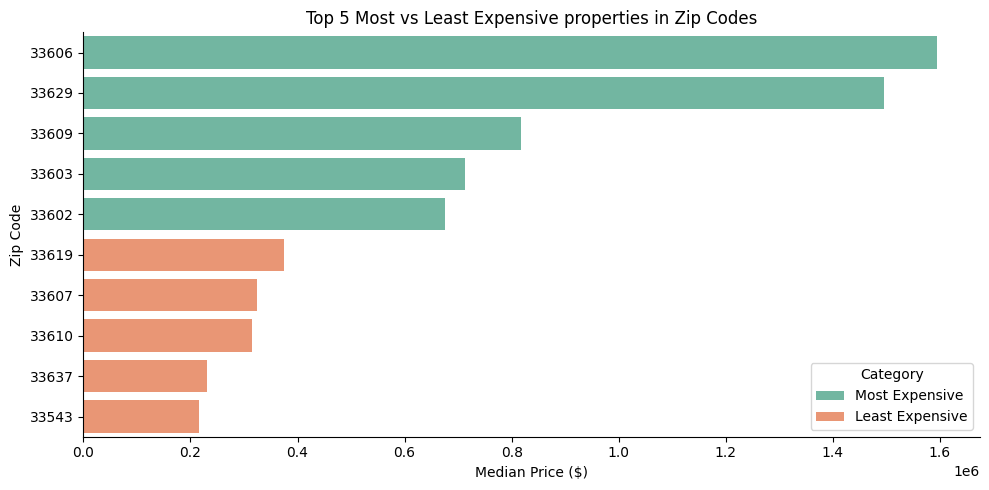

In [28]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=for_plot,
    x='Price',
    y='ZipCode',
    hue='Category',
    palette='Set2'
)

plt.title('Top 5 Most vs Least Expensive properties in Zip Codes')
plt.xlabel('Median Price ($)')
plt.ylabel('Zip Code')

sns.despine()
plt.tight_layout()
plt.show()

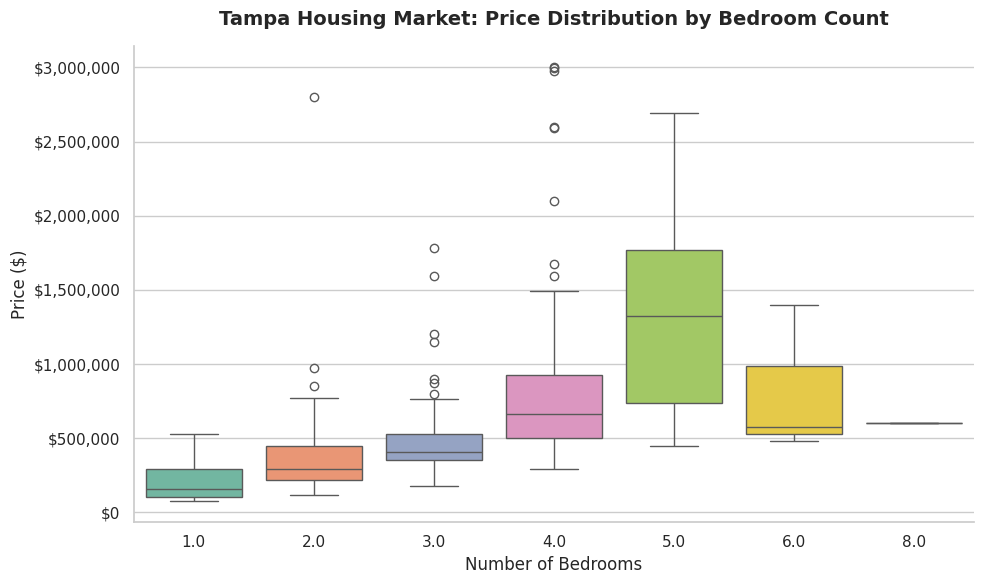

In [29]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

# Made a beds df from 1 to 8
df_beds = df[df["Beds"].isin([1, 2, 3, 4, 5, 6, 7, 8])]

sns.boxplot(data=df_beds, x="Beds", y="Price", palette="Set2", hue="Beds", legend=False, ax=ax)

# Formatting
ax.set_title("Tampa Housing Market: Price Distribution by Bedroom Count", fontsize=14, pad=15, fontweight="bold")
ax.set_xlabel("Number of Bedrooms", fontsize=12)
ax.set_ylabel("Price ($)", fontsize=12)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"${int(x):,}"))

plt.tight_layout()
sns.despine()
plt.show()

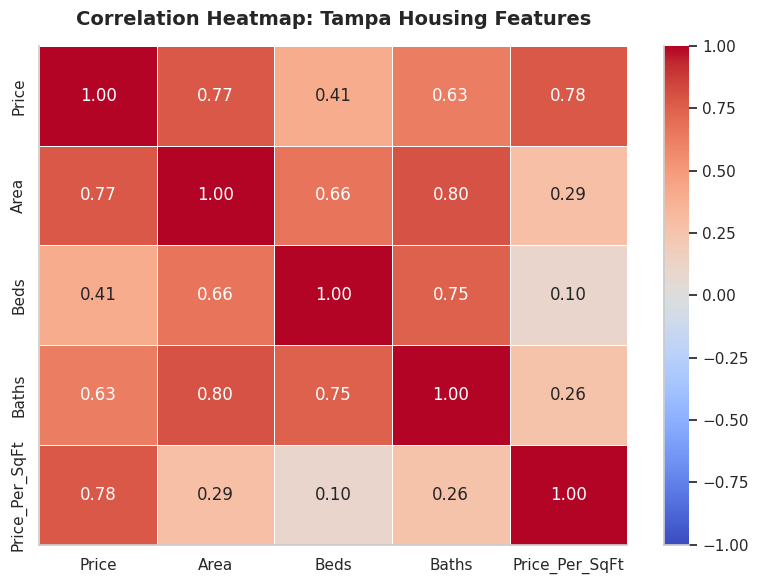

In [30]:
fig, ax = plt.subplots(figsize=(8, 6))

# Isolate numeric columns for correlation matrix
matrix_cols = ["Price", "Area", "Beds", "Baths","Price_Per_SqFt"]
correlation_matrix = df[matrix_cols].corr()

# Create Heatmap
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, vmin=-1, vmax=1, ax=ax)

ax.set_title("Correlation Heatmap: Tampa Housing Features", fontsize=14, pad=15, fontweight="bold")

plt.tight_layout()
sns.despine()
plt.show()

Property Area shares the strongest linear relationship with Price, while the number of Bedrooms shows a much weaker direct correlation, indicating space volume drives value more heavily than room partitions in the Tampa market.